In [3]:
import math#python自带的数学库
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors#颜色模块,可以颜色转换,有调色板
from matplotlib.patches import Rectangle#导入图形对象模块的矩形类

In [31]:
#*后的参数必须用关键词传入
def plot_colortable(colors,*,ncols = 4,sort_colors = True):

    cell_width = 212
    cell_height = 22
    swatch_width = 48#色块宽度,单位都是像素
    margin = 12#外边距

    #如果排序
    if sort_colors is True:
        #按照key参数排序colors列表
        names = sorted(
            #tohsv只接受rgb,所以需要先传rgb
            #tuple转换为可比较的三值元组,sorted自动对元组排序
            colors,key = lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
    else:
        #可能是字典,变成列表,列表只保留键
        names = list(colors)

    n = len(names)
    #求出一共有多少行,ceil是向上取整
    nrows = math.ceil(n/ncols)

    width = cell_width * ncols + 2*margin
    height = cell_height*nrows + 2*margin
    dpi = 72#每英寸多少个像素点

    fig,ax = plt.subplots(figsize = (width / dpi,height/dpi),dpi = dpi)
    #设置边界,左低右上,改变画布上的子图位置
    #边界必须是0-1的比例值
    fig.subplots_adjust(margin/width,margin/height,(width - margin)/width,(height-margin)/height)
    ax.set_xlim(0,cell_width*ncols)
    #y轴翻转,从上向下排序
    ax.set_ylim(cell_height*(nrows - 0.5),-cell_height/2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    #关整个轴坐标区域可见元素,包括脊
    ax.set_axis_off()

    for i,name in enumerate(names):
        #这是按列排列算法,不是按照行
        row = i%nrows
        col = i//nrows
        #计算色块位置
        y = row*cell_height
        swatch_start_x = cell_width * col
        text_pos_x = cell_width*col + swatch_width +7

        ax.text(text_pos_x,y,name,fontsize = 14,
        horizontalalignment = 'left',
        verticalalignment = 'center')

        ax.add_patch(
            Rectangle(xy = (swatch_start_x,y - 9),width = swatch_width,
            height = 18,facecolor = colors[name],edgecolor = '0.7')
        )

    return fig

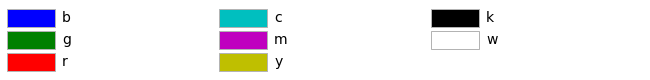

In [41]:
plot_colortable(mcolors.BASE_COLORS,ncols = 3,sort_colors = False)
plt.show()

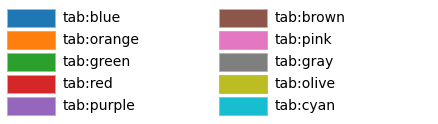

In [43]:
plot_colortable(mcolors.TABLEAU_COLORS,ncols = 2,sort_colors = False)
plt.show()

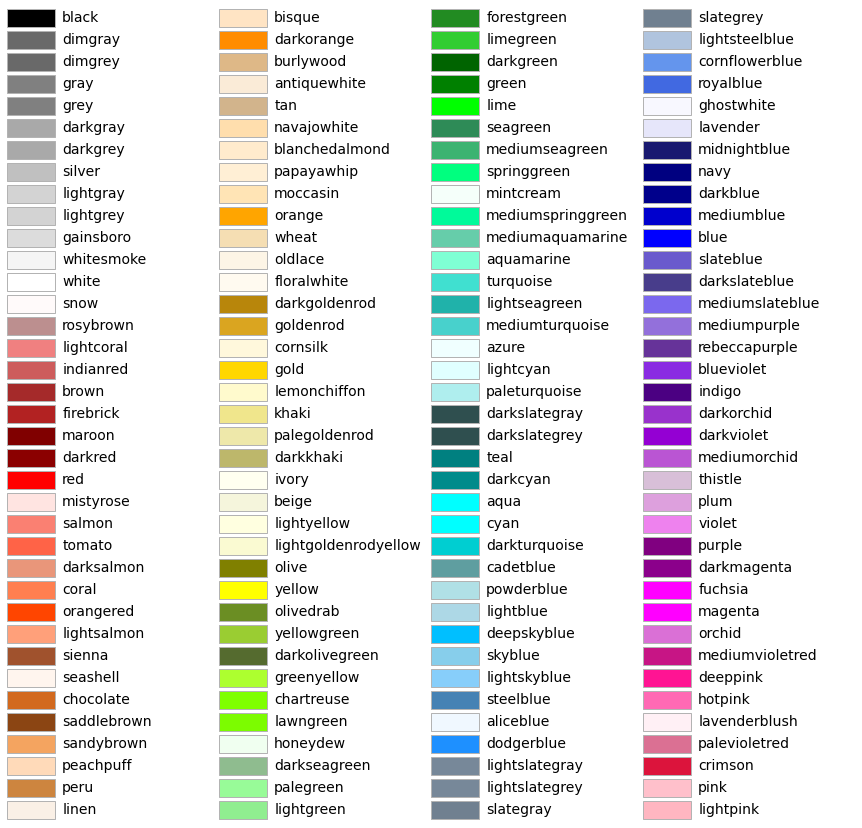

In [45]:
plot_colortable(mcolors.CSS4_COLORS)
plt.show()

In [49]:
import matplotlib.pyplot as plt
import numpy as np

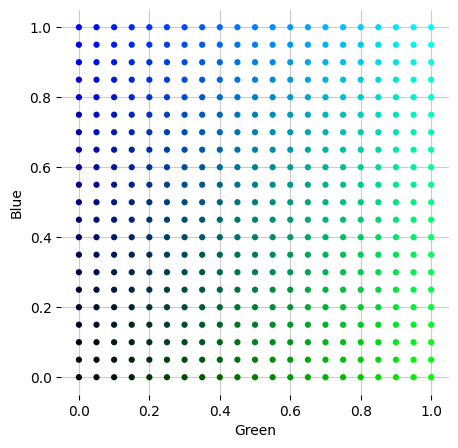

In [59]:
num_points = 21
Green_array = np.linspace(0,1,num_points)
Blue_array = np.linspace(0,1,num_points)

GG,BB = np.meshgrid(Green_array,Blue_array)

RR = np.zeros_like(GG)#红色这里为0

RGB_colors = np.vstack([RR.ravel(),GG.ravel(),BB.ravel()]).T

fig,ax = plt.subplots(figsize = (5,5))
ax.scatter(GG,BB,c = RGB_colors,s = 12)

ax.set_xlabel('Green')
ax.set_ylabel('Blue')

ax.set_xlim(-0.05,1.05)
ax.set_ylim(-0.05,1.05)
ax.set_xticks(np.linspace(0,1,6))
ax.set_yticks(np.linspace(0,1,6))
plt.grid(color = (0.8,0.8,0.8))
ax.set_axisbelow(True)

ax.spines[['top','right','left','bottom']].set_visible(False)
fig.savefig('Figures/蓝绿平面.svg',format = 'svg')

In [61]:
RGB_colors

array([[0.  , 0.  , 0.  ],
       [0.  , 0.05, 0.  ],
       [0.  , 0.1 , 0.  ],
       ...,
       [0.  , 0.9 , 1.  ],
       [0.  , 0.95, 1.  ],
       [0.  , 1.  , 1.  ]])

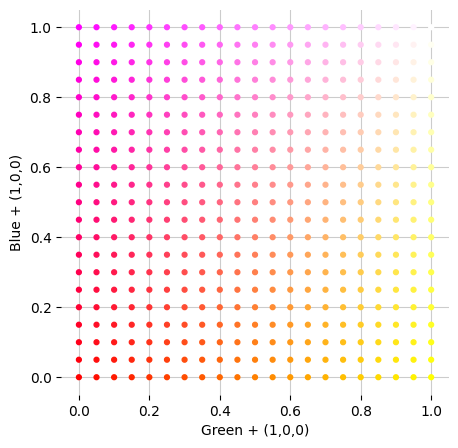

In [67]:
RR = np.ones_like(GG)#平移,所有的R都为1
RGB_colors = np.vstack([RR.ravel(),GG.ravel(),BB.ravel()]).T

fig,ax = plt.subplots(figsize = (5,5))
ax.scatter(GG,BB,c = RGB_colors,s = 12)

ax.set_xlabel('Green + (1,0,0)')
ax.set_ylabel('Blue + (1,0,0)')

ax.set_xlim(-0.05,1.05)
ax.set_ylim(-0.05,1.05)
ax.set_xticks(np.linspace(0,1,6))
ax.set_yticks(np.linspace(0,1,6))
plt.grid(color = (0.8,0.8,0.8))
#将网格和刻度线都放在最底层
ax.set_axisbelow(True)

ax.spines[['top','right','left','bottom']].set_visible(False)

fig.savefig('Figures/蓝绿_red_1.svg',format = 'svg')

In [69]:
#红蓝渐变

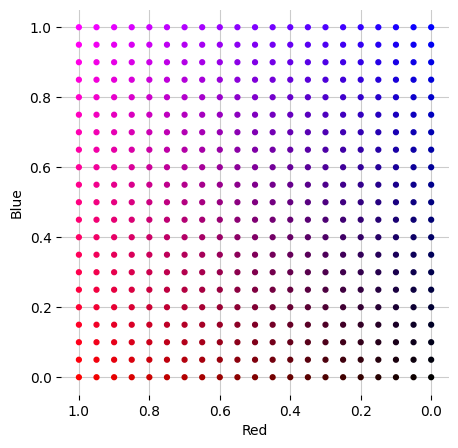

In [83]:
XX,YY = np.meshgrid(np.linspace(0,1,num_points),np.linspace(0,1,num_points))

All_0s = XX*0#0矩阵

RGB_colors = np.vstack([XX.ravel(),All_0s.ravel(),YY.ravel()]).T

fig,ax = plt.subplots(figsize = (5,5))
#代码会内部执行XX和YY的展平,所以与c的(N,3)对应
ax.scatter(XX,YY,c = RGB_colors,s = 12)

ax.set_xlim(-0.05,1.05)
ax.set_ylim(-0.05,1.05)
ax.set_xticks(np.linspace(0,1,6))
ax.set_yticks(np.linspace(0,1,6))
plt.grid(color = (0.8,0.8,0.8))
#将网格和刻度线都放在最底层
ax.set_axisbelow(True)

ax.set_xlabel('Red')
ax.set_ylabel('Blue')

#获取当前轴对象,翻转x轴
plt.gca().invert_xaxis()

ax.spines[['top','right','left','bottom']].set_visible(False)

fig.savefig('Figures/红蓝.svg',format = 'svg')

In [85]:
#红蓝渐变+绿

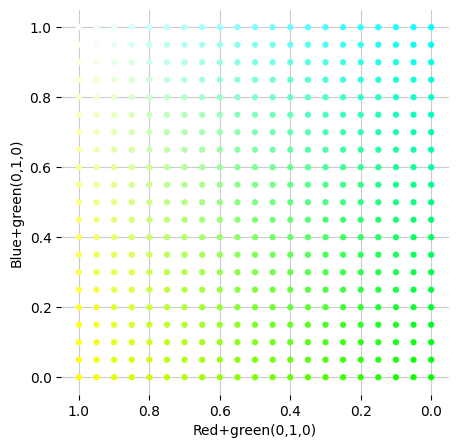

In [87]:
XX,YY = np.meshgrid(np.linspace(0,1,num_points),np.linspace(0,1,num_points))

All_1s = XX*0 + 1 #1矩阵

RGB_colors = np.vstack([XX.ravel(),All_1s.ravel(),YY.ravel()]).T

fig,ax = plt.subplots(figsize = (5,5))
#代码会内部执行XX和YY的展平,所以与c的(N,3)对应
ax.scatter(XX,YY,c = RGB_colors,s = 12)

ax.set_xlim(-0.05,1.05)
ax.set_ylim(-0.05,1.05)
ax.set_xticks(np.linspace(0,1,6))
ax.set_yticks(np.linspace(0,1,6))
plt.grid(color = (0.8,0.8,0.8))
#将网格和刻度线都放在最底层
ax.set_axisbelow(True)

ax.set_xlabel('Red+green(0,1,0)')
ax.set_ylabel('Blue+green(0,1,0)')

#获取当前轴对象,翻转x轴
plt.gca().invert_xaxis()

ax.spines[['top','right','left','bottom']].set_visible(False)

fig.savefig('Figures/红蓝_green_1.svg',format = 'svg')

In [89]:
#红绿渐变

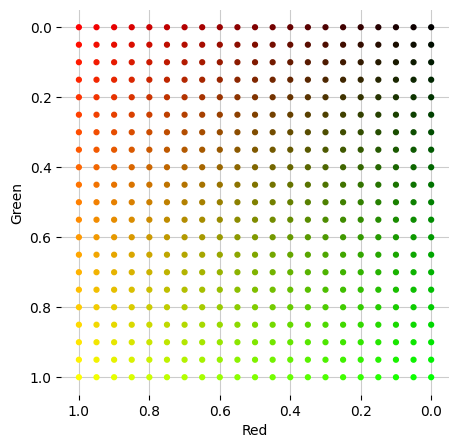

In [95]:
RGB_colors = np.vstack([XX.ravel(),YY.ravel(),All_0s.ravel()]).T

fig,ax = plt.subplots(figsize = (5,5))
ax.scatter(XX,YY,c = RGB_colors,s = 12)
ax.set_xlim(-0.05,1.05)
ax.set_ylim(-0.05,1.05)
ax.set_xticks(np.linspace(0,1,6))
ax.set_yticks(np.linspace(0,1,6))
plt.grid(color = (0.8,0.8,0.8))
ax.set_axisbelow(True)

ax.set_xlabel('Red')
ax.set_ylabel('Green')

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

ax.spines[['top','right','left','bottom']].set_visible(False)

fig.savefig('Figures/红绿.svg',format = 'svg')

In [97]:
#红绿渐变+蓝

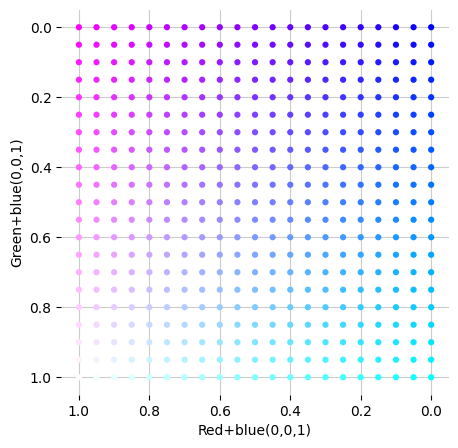

In [99]:
RGB_colors = np.vstack([XX.ravel(),YY.ravel(),All_1s.ravel()]).T

fig,ax = plt.subplots(figsize = (5,5))
ax.scatter(XX,YY,c = RGB_colors,s = 12)
ax.set_xlim(-0.05,1.05)
ax.set_ylim(-0.05,1.05)
ax.set_xticks(np.linspace(0,1,6))
ax.set_yticks(np.linspace(0,1,6))
plt.grid(color = (0.8,0.8,0.8))
ax.set_axisbelow(True)

ax.set_xlabel('Red+blue(0,0,1)')
ax.set_ylabel('Green+blue(0,0,1)')

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

ax.spines[['top','right','left','bottom']].set_visible(False)

fig.savefig('Figures/红绿_blue_1.svg',format = 'svg')

In [102]:
import numpy as np
import matplotlib.pyplot as plt

In [104]:
def color_cubic(num):
    x1 = np.linspace(0,1,num)
    x2 = x1
    x3 = x2

    xx1,xx2,xx3 = np.meshgrid(x1,x2,x3)

    x1_ = xx1.ravel()
    x2_ = xx2.ravel()
    x3_ = xx3.ravel()

    colors_all = np.column_stack([x1_,x2_,x3_])

    #any是特殊函数,检查某一轴是否有true
    #先用==生成布尔矩阵,然后逐个行检查是否有true
    #用生成的一维布尔数组取出点,进操作最外层取出需要操作的整行,结果还是二维数组.结果列数不变去除了false对应的行
    colors_bright = colors_all[np.any(colors_all == 1,axis = 1
    colors_dark = colors_all[np.any(colors_all == 0,axis = 1)]

    return colors_all,colors_bright,colors_dark

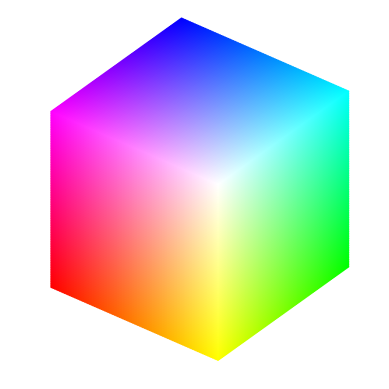

In [150]:
colors_all,colors_bright,colors_dark = color_cubic(101)

fig = plt.figure()
ax = fig.add_subplot(111,projection = '3d')

ax.scatter(colors_bright[:,0],
           colors_bright[:,1],
           colors_bright[:,2],
           c = colors_bright,
           s = 1,
           alpha = 1)

ax.view_init(azim = 38,elev = 34)

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_zlim(0,1)

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

#将每个轴的背景面去除
#z对应的面就是xy平面,但是只绑定周,所以方便表示绑定到垂直的轴上,其他平面同理
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')

ax.grid(False)

ax.set_proj_type('ortho')

ax.set_box_aspect(aspect = (1,1,1))

#旧版本
#ax.w_xaxis.line.set_color((1.0,1.0,1.0,0.0))
#新版本
ax.xaxis.line.set_color((1,1,1,0))
ax.yaxis.line.set_color((1,1,1,0))
ax.zaxis.line.set_color((1,1,1,0))
#前面已经配置了pane为False,不显示了,就不用配置了
#这是修改pane的颜色
#pane本意就是面板,这里是为了辅助显示
ax.xaxis.set_pane_color((1.0,1.0,1.0,0))
ax.yaxis.set_pane_color((1.0,1.0,1.0,0))

fig.savefig('Figures/完全填充立方体,最艳丽的三个立面.svg',format = 'svg')

In [152]:
#彩色空间采样

In [154]:
colors_all,colors_bright,colors_dark = color_cubic(21)

#这是两个点,竖着看,对应了后面的输入
line1_x = [1,1]
line1_y = [1,1]
line1_z = [1,0]

line2_x = [1,1]
line2_y = [1,0]
line2_z = [1,1]

line3_x = [1,0]
line3_y = [1,1]
line3_z = [1,1]

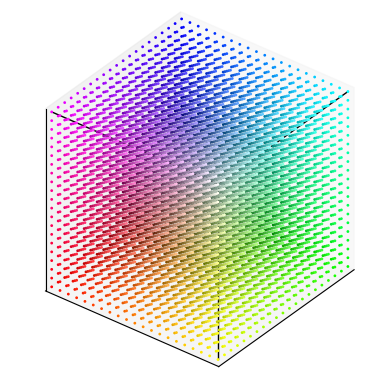

In [174]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1,projection = '3d')

ax.scatter(colors_all[:,0],
           colors_all[:,1],
           colors_all[:,2],
           c = colors_all,
           s = 1,
           alpha = 1)

#初始化角度,其实使用这个初始化函数配置角度
ax.view_init(azim = 30,elev = 30)
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_zlim(0,1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

#这里是将所有的点的x坐标传入,而不是一次传入一个三个元素的对应点.
ax.plot(line1_x,line1_y,line1_z,alpha = 1,linewidth = 1,color = 'k')
ax.plot(line2_x,line2_y,line2_z,alpha = 1,linewidth = 1,color = 'k')
ax.plot(line3_x,line3_y,line3_z,alpha = 1,linewidth = 1,color = 'k')

ax.set_proj_type('ortho')
ax.set_box_aspect(aspect = (1,1,1))
ax.view_init(azim = 38,elev = 34)

fig.savefig('Figures/整个色彩空间采样,稀疏.svg',format = 'svg')

In [176]:
#颗粒度降低

In [204]:
colors_all,colors_bright,colors_dark = color_cubic(51)

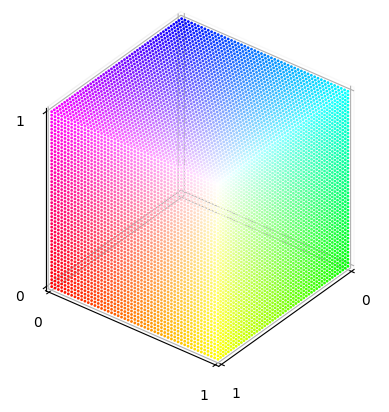

In [211]:
fig = plt.figure()
ax = fig.add_subplot(111,projection = '3d')
ax.scatter(colors_bright[:,0],
           colors_bright[:,1],
           colors_bright[:,2],
           c = colors_bright,
           s = 1,
           alpha = 1)

ax.view_init(azim = 38,elev = 34)
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_zlim(0,1)
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_zticks([0,1])
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.set_proj_type('ortho')
ax.set_box_aspect(aspect = (1,1,1))

fig.savefig('Figures/立方体最艳丽的的三个面_颗粒度降低.svg',format = 'svg')

In [215]:
#立方体最暗淡的三个面

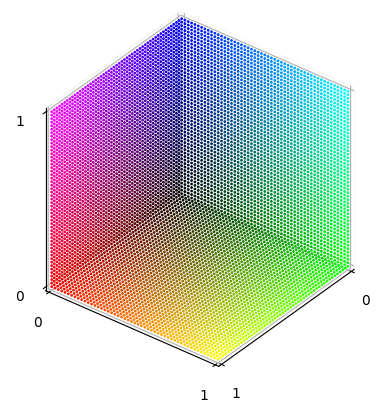

In [225]:
fig = plt.figure()
ax = fig.add_subplot(111,projection = '3d')
ax.scatter(colors_dark[:,0],
           colors_dark[:,1],
           colors_dark[:,2],
           c = colors_dark,
           s = 1,
           alpha = 1)

ax.view_init(azim = 30,elev = 30)
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_zlim(0,1)
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_zticks([0,1])
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.set_proj_type('ortho')
ax.set_box_aspect(aspect = (1,1,1))
ax.view_init(azim = 38,elev = 34)

fig.savefig('Figures/立方体最暗淡的三个面_降低颗粒度.svg',format = 'svg')

In [227]:
#绘制6个侧面,三维散点

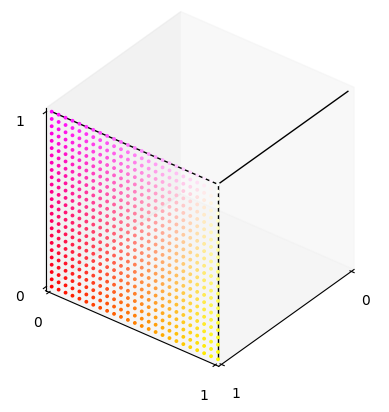

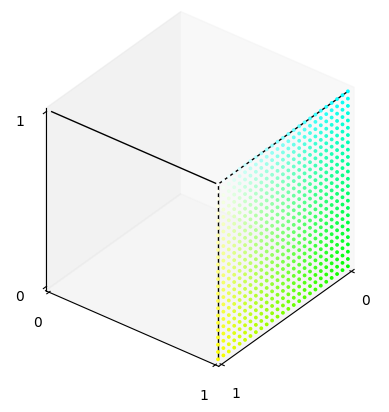

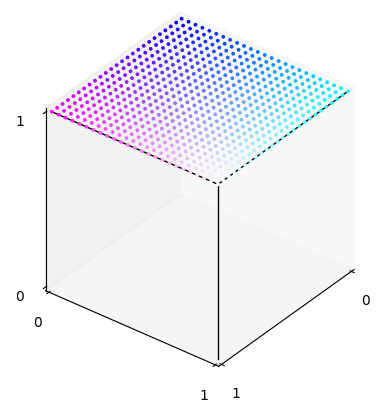

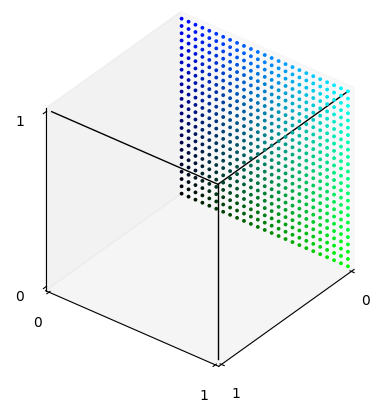

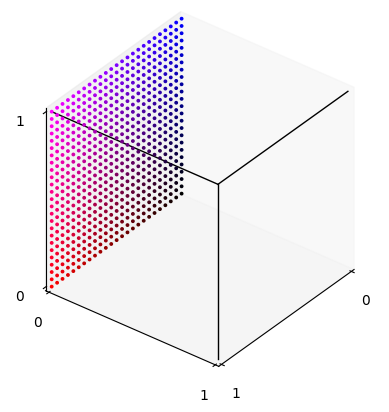

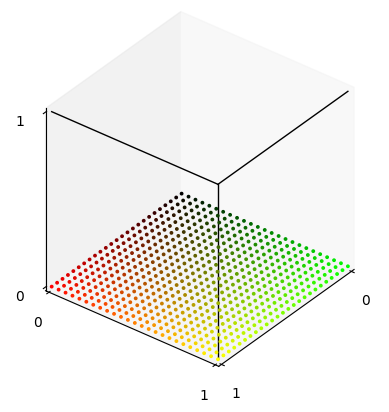

In [245]:
colors_all,colors_bright,colors_dark = color_cubic(25)

#筛选6个侧面
facets_6 = [colors_all[colors_all[:,0] == 1],#名面
            colors_all[colors_all[:,1] == 1],
            colors_all[colors_all[:,2] == 1],
            colors_all[colors_all[:,0] == 0],#暗面
            colors_all[colors_all[:,1] == 0],
            colors_all[colors_all[:,2] == 0]]

for idx,colors_one_facet in enumerate(facets_6):
    #每一次生成新的fig,不会覆盖上一个fig,仅仅是变量名改变,之前的fig依旧存储在内存中
    #jupyter自动捕捉所有本单元格内存中fig显示
    fig = plt.figure()
    ax = fig.add_subplot(111,projection = '3d')

    ax.plot(line1_x,line1_y,line1_z,alpha = 1,linewidth = 1,color = 'k')
    ax.plot(line2_x,line2_y,line2_z,alpha = 1,linewidth = 1,color = 'k')
    ax.plot(line3_x,line3_y,line3_z,alpha = 1,linewidth = 1,color = 'k')

    ax.scatter(colors_one_facet[:,0],
                colors_one_facet[:,1],
                colors_one_facet[:,2],
                c = colors_one_facet,
                s = 3,alpha = 1)

    ax.view_init(azim = 30,elev = 30)
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_zlim(0,1)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_zticks([0,1])

    ax.grid(False)
    ax.set_proj_type('ortho')
    ax.set_box_aspect(aspect = (1,1,1))
    ax.view_init(azim = 38,elev = 34)

    fig.savefig('Figures/六个立面_' + str(idx +1) + '.svg',format = 'svg')